<a id="section4"></a>

---

## §4 Part 2 — Clustering of Faces


### 4.1 — Load data

In [1]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RANDOM_STATE = 42

data, targets = fetch_olivetti_faces(return_X_y=True)

IMG_SHAPE = (64, 64)
n_samples, n_features = data.shape
classes = np.unique(targets)
n_classes = len(classes)

assert n_features == 64 * 64

print(f"Samples: {n_samples}")
print(f"Features (pixels): {n_features}")
print(f"Distinct identities (labels 0–{n_classes-1}): {n_classes}")
print(f"Intensity range [{data.min():.3f}, {data.max():.3f}]")

Samples: 400
Features (pixels): 4096
Distinct identities (labels 0–39): 40
Intensity range [0.000, 1.000]


**Description.** *(a)* **400** photos — **40** subjects, **10** captures each variant lighting/pose/emotion.
 *(b)* **4096** features = flattened **64×64** intensities aligned with sklearn’s raster order.

### 4.2 — Stratified-at-random gallery (one image per identity)

`RNG_PART2` fixes the RNG stream for repeatable sampling.

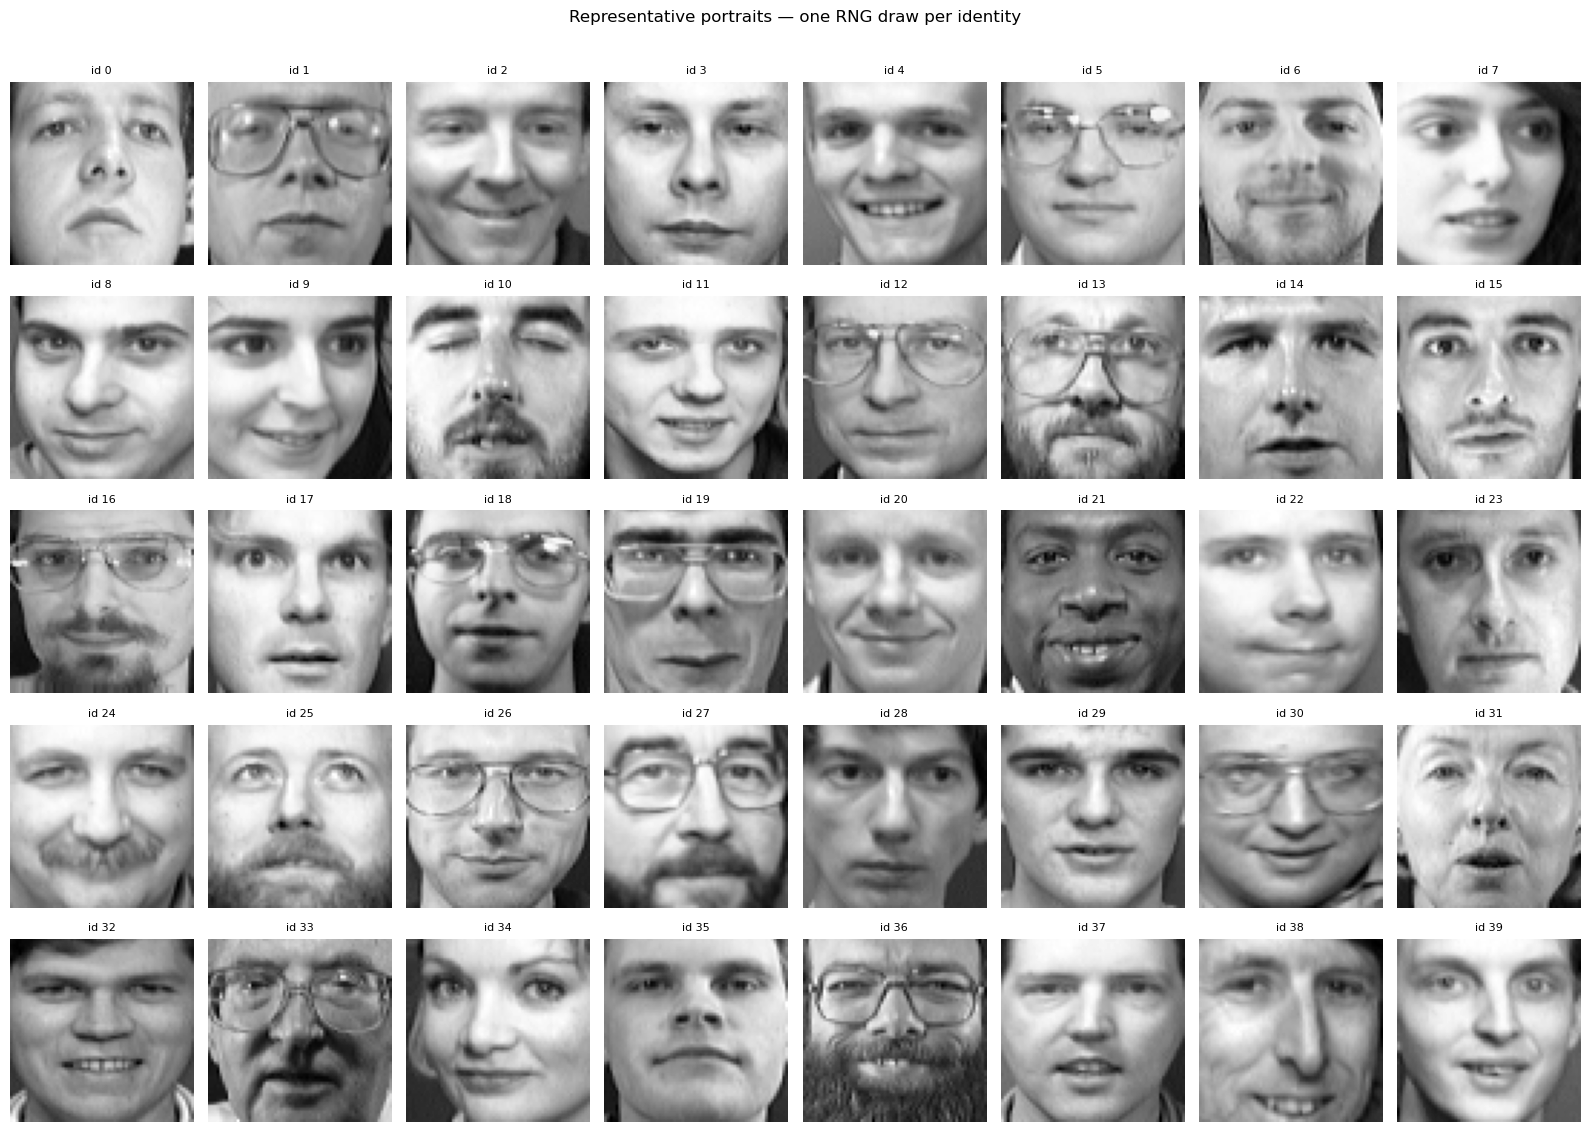

In [2]:
RNG_PART2 = np.random.default_rng(2026)

n_cols = 8
n_rows = int(np.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2.25 * n_rows))
axes = np.atleast_1d(axes).ravel()

for cid in range(n_classes):
    pool = np.flatnonzero(targets == cid)
    idx = int(RNG_PART2.choice(pool))
    axes[cid].imshow(data[idx].reshape(IMG_SHAPE), cmap="gray")
    axes[cid].set_title(f"id {cid}", fontsize=8)
    axes[cid].axis("off")

for k in range(n_classes, len(axes)):
    axes[k].axis("off")
plt.suptitle("Representative portraits — one RNG draw per identity", y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Principal component analysis

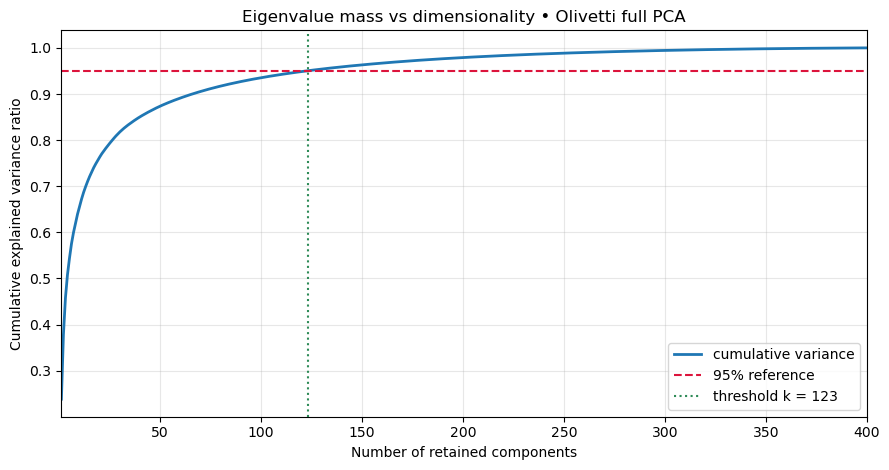

Minimal k attaining ≥95% variance: k = 123
Actual cumulative variance at k: 0.95039


In [3]:
from sklearn.decomposition import PCA

X_faces = data

pca_curve = PCA(svd_solver="randomized", random_state=RANDOM_STATE)
pca_curve.fit(X_faces)

cum_evr = np.cumsum(pca_curve.explained_variance_ratio_)
n95 = int(np.searchsorted(cum_evr, 0.95) + 1)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(np.arange(1, len(cum_evr) + 1), cum_evr, lw=2, label="cumulative variance")
ax.axhline(0.95, color="crimson", ls="--", label="95% reference")
ax.axvline(n95, color="seagreen", ls=":", label=f"threshold k = {n95}")
ax.set_xlim(1, min(420, len(cum_evr)))
ax.set_xlabel("Number of retained components")
ax.set_ylabel("Cumulative explained variance ratio")
ax.set_title("Eigenvalue mass vs dimensionality • Olivetti full PCA")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Minimal k attaining ≥95% variance: k = {n95}")
print(f"Actual cumulative variance at k: {cum_evr[n95-1]:.5f}")

#### Task eigenfaces visualization
First **10** principal axes reshaped — **spatial harmonic patterns** orthogonal in pixel-inner-product geometry; projecting any centred face obtains scores that linearly recombine eigenfaces.

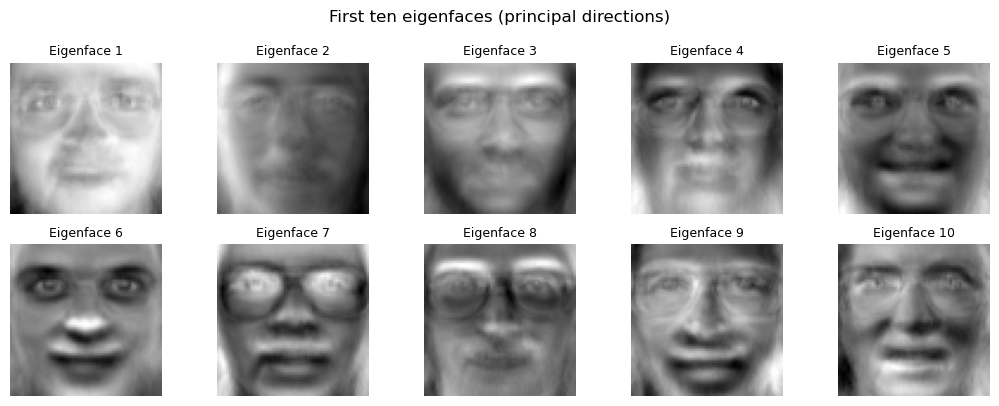

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10.5, 4.1))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(pca_curve.components_[i].reshape(IMG_SHAPE), cmap="gray")
    ax.set_title(f"Eigenface {i+1}", fontsize=9)
    ax.axis("off")
plt.suptitle("First ten eigenfaces (principal directions)")
plt.tight_layout()
plt.show()

#### Two-dimensional PCA scatter
Only **two** coordinates cannot faithfully separate forty identities — extensive overlap confirms high intrinsic mixing under linear PCA.

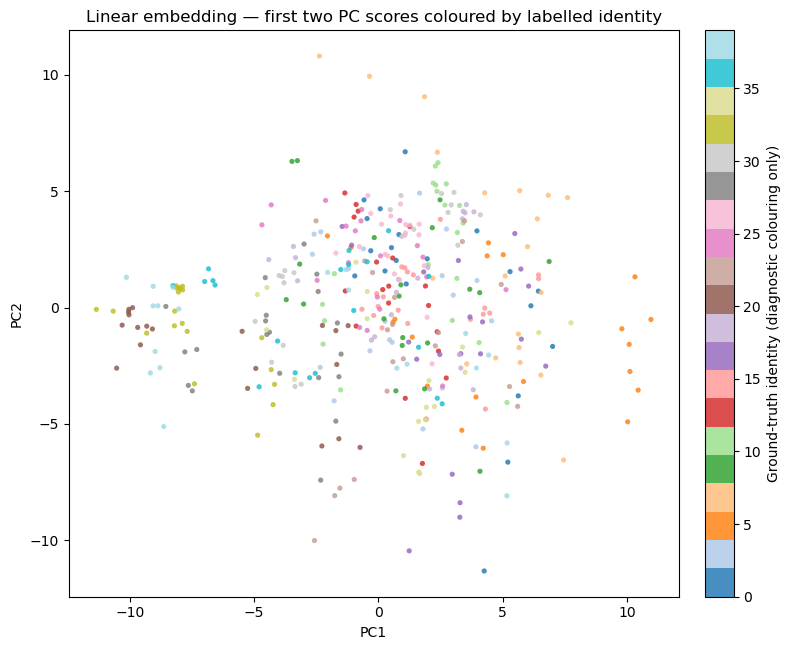

In [5]:
scores2 = pca_curve.transform(X_faces)[:, :2]

fig, ax = plt.subplots(figsize=(8, 6.6))
scatter = ax.scatter(scores2[:, 0], scores2[:, 1], c=targets, cmap="tab20", s=14, alpha=0.82, lw=0)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Linear embedding — first two PC scores coloured by labelled identity")
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Ground-truth identity (diagnostic colouring only)")
plt.tight_layout()
plt.show()

### 4.4 k-means in ambient pixel space (k = 40)

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

k_clusters = n_classes

km_pixel = KMeans(n_clusters=k_clusters, n_init="auto", random_state=RANDOM_STATE)
labels_pixel = km_pixel.fit_predict(X_faces)
sil_pixel = silhouette_score(X_faces, labels_pixel)
print(f"Silhouette (raw pixels): {sil_pixel:.4f}")

Silhouette (raw pixels): 0.1294


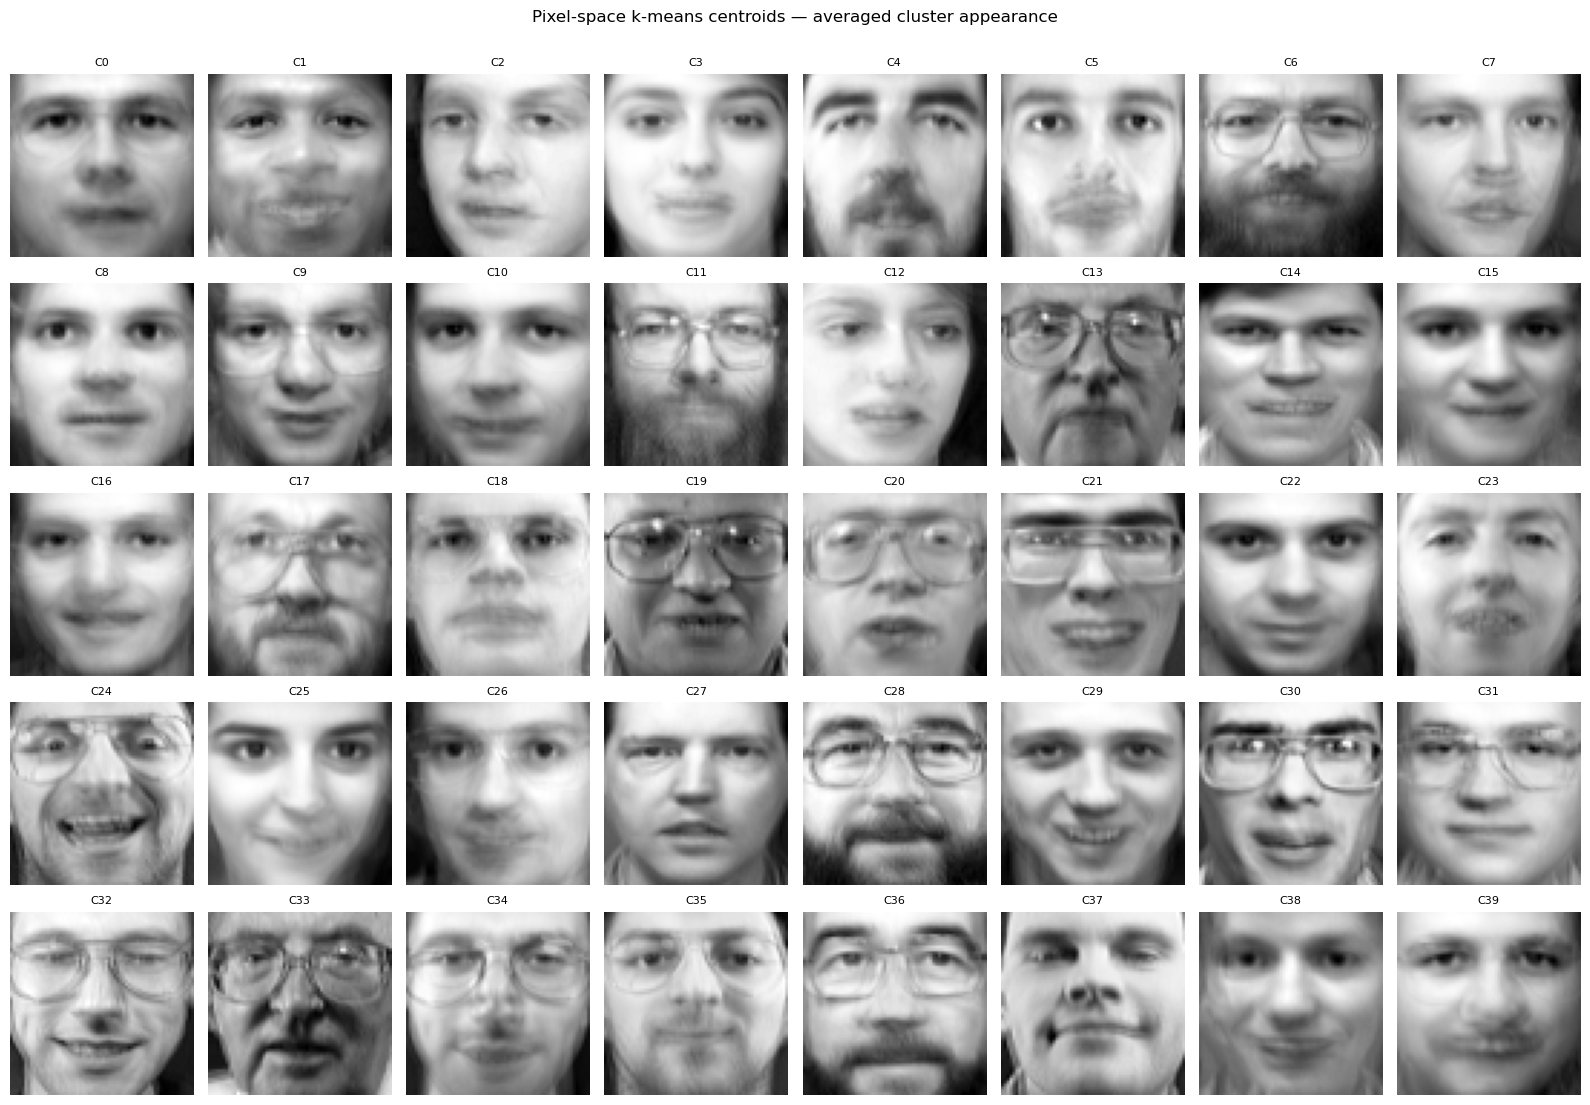

In [7]:
centroids = km_pixel.cluster_centers_.reshape(k_clusters, *IMG_SHAPE)
n_cols_c = 8
n_rows_c = int(np.ceil(k_clusters / n_cols_c))
fig, axes = plt.subplots(n_rows_c, n_cols_c, figsize=(2 * n_cols_c, 2.2 * n_rows_c))
axes = np.atleast_1d(axes).ravel()

for i in range(k_clusters):
    axes[i].imshow(centroids[i], cmap="gray")
    axes[i].set_title(f"C{i}", fontsize=8)
    axes[i].axis("off")
for j in range(k_clusters, len(axes)):
    axes[j].axis("off")
plt.suptitle("Pixel-space k-means centroids — averaged cluster appearance", y=1.005)
plt.tight_layout()
plt.show()

**Centroids versus eigenfaces.** Eigenfaces optimise **global** variance orthogonal axes; centroids depict **within-cluster empirical means**. Centroids resemble smoothed composites; eigenfaces resemble edge / lighting templates — different mathematical objects answering different optimisation problems.

### 4.5 k-means on PCA scores (dimension = $k_{95}$) + silhouette juxtaposition

In [8]:
pca_reduced = PCA(
    n_components=n95,
    svd_solver="randomized",
    random_state=RANDOM_STATE,
)
X_repr = pca_reduced.fit_transform(X_faces)

km_sub = KMeans(n_clusters=k_clusters, n_init="auto", random_state=RANDOM_STATE)
labels_sub = km_sub.fit_predict(X_repr)
sil_sub = silhouette_score(X_repr, labels_sub)

print(f"Silhouette (PCA subspace dim={n95}): {sil_sub:.4f}")
print(f"Δ silhouette vs raw pixels (PCA − pixel): {sil_sub - sil_pixel:+.4f}")

Silhouette (PCA subspace dim=123): 0.1787
Δ silhouette vs raw pixels (PCA − pixel): +0.0493


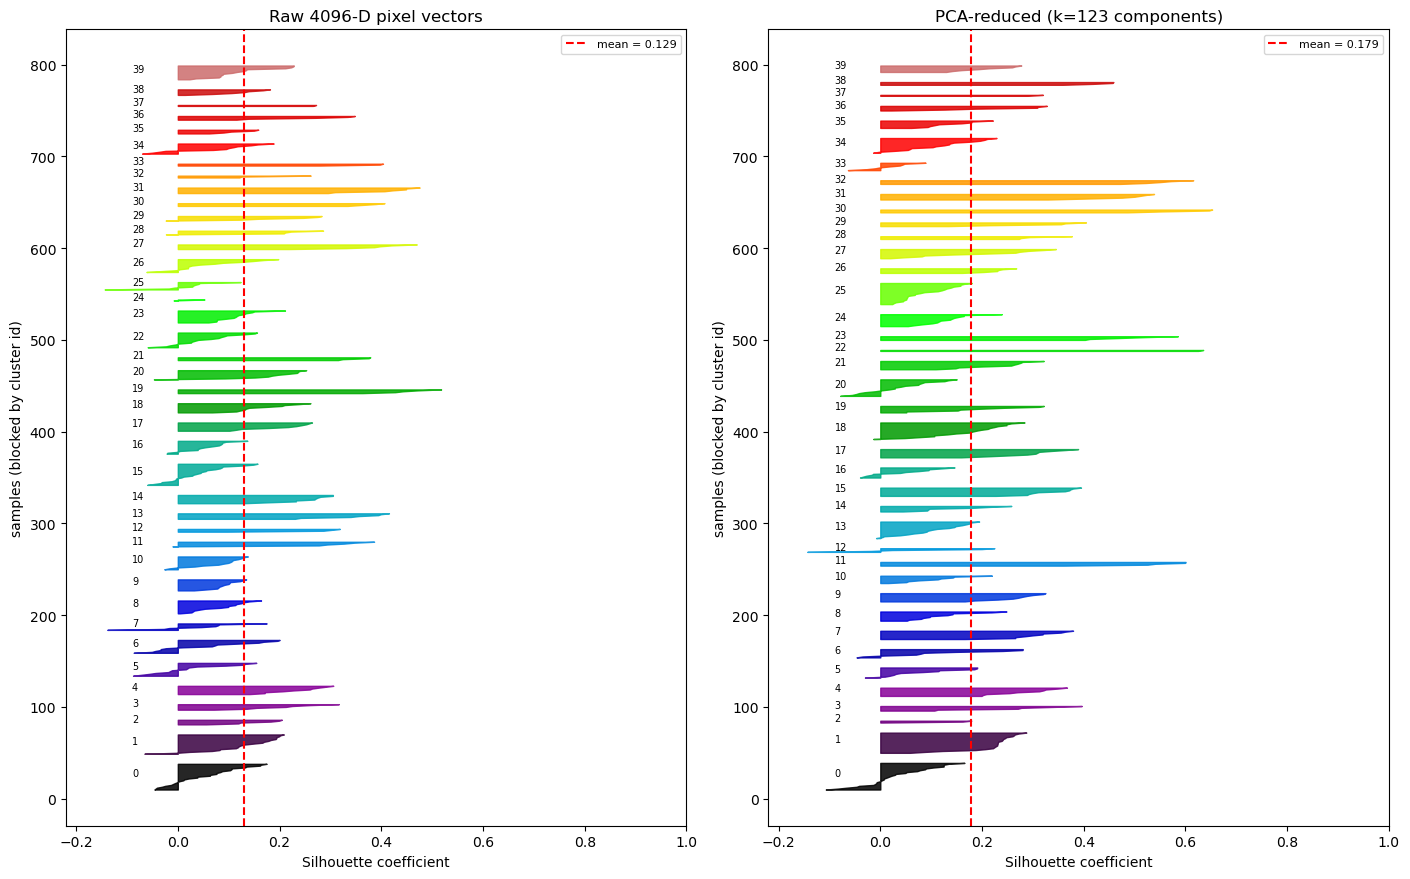

In [9]:
def draw_silhouette(Xmat, lbl, axis, ttl):
    """Compact silhouette stacking per cluster label."""
    ncl = len(np.unique(lbl))
    avg = silhouette_score(Xmat, lbl)
    samp = silhouette_samples(Xmat, lbl)
    ymin = 10
    for i in np.arange(ncl):
        wedge = samp[lbl == i]
        wedge.sort()
        height = wedge.shape[0]
        ymax = ymin + height
        colour = plt.cm.nipy_spectral(i / max(ncl, 1))
        axis.fill_betweenx(np.arange(ymin, ymax), 0.0, wedge, facecolor=colour, edgecolor=colour, alpha=0.85)
        axis.text(-0.09, ymin + height / 2, str(i), fontsize=7)
        ymin = ymax + 10
    axis.axvline(avg, color="red", ls="--", label=f"mean = {avg:.3f}")
    axis.set_title(ttl)
    axis.set_xlabel("Silhouette coefficient")
    axis.set_ylabel("samples (blocked by cluster id)")
    axis.set_xlim(-0.22, 1.0)
    axis.legend(fontsize=8, loc="upper right")


fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14.2, 8.9))
draw_silhouette(X_faces, labels_pixel, ax_left, "Raw 4096-D pixel vectors")
draw_silhouette(X_repr, labels_sub, ax_right, f"PCA-reduced (k={n95} components)")
plt.tight_layout()
plt.show()

**Diagram reading guide.** Bands extending beyond the dashed **mean** silhouette suggest internally coherent Voronoi cells; pervasive negative wedges flag points closer to alien centroids. Comparing canvases diagnoses whether PCA concentrates mass rightward (**distance denoising**) or fails if discarded variance still harboured discriminative quirks.

### 4.6 — Discussion

**(a)** Silhouette **comparisons** answer whether PCA-guided geometry improves intrinsic cohesion versus raw pixels for **this** $k$ and split-free setting. A **positive Δ** is consistent with suppressing high-variance noise coordinates; a **negative Δ** would stress that retained PCs still entangle subjects or that linear variance objectives miss identity directions.

**(b)** **PCA→k-means upsides:** fewer Lloyd iterations, mitigated curse of dimensionality, interpretable variance budget (95% rule). **Downsides:** linearity assumption, irreversible truncation, variance ≠ identity separability, loss of micro-texture cues.